# Monte Carlo Simulation: Enterprise Customer Adoption Opportunity

## Enterprise Customer Adoption Opportunity for Amazon Connect and AWS Bedrock

This notebook supports the quantitative risk assessment section of the report. The purpose is to model uncertainty in enterprise customer adoption for Amazon Connect and AWS Bedrock using a Monte Carlo simulation.

The model follows the same general structure used in the course Monte Carlo example: define assumptions, simulate many possible outcomes, summarize the results, visualize the distribution, and interpret the results for risk decision-making.

## 1. Problem Statement

How can Amazon increase enterprise customer adoption of Amazon Connect and AWS Bedrock while maintaining customer retention and competitive advantage in the AI-powered customer service market?

Because actual future adoption cannot be known with certainty, this notebook uses Monte Carlo simulation to estimate a range of possible enterprise adoption outcomes rather than relying on one fixed number.

## 2. Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Simulation Assumptions

Actual enterprise adoption data for Amazon Connect and AWS Bedrock expansion is not publicly available. Therefore, a three-point estimation approach is used.

The three estimates represent possible adoption scenarios:

| Scenario | Enterprise Adoption Rate | Rationale |
|---|---:|---|
| Pessimistic | 10% | Adoption is slow due to competitive pressure, implementation complexity, privacy concerns, and customer hesitation toward generative AI service platforms. |
| Most Likely | 20% | Adoption grows steadily because Amazon benefits from AWS infrastructure, existing enterprise relationships, and increasing demand for AI-powered customer service automation. |
| Optimistic | 30% | Adoption accelerates because Amazon successfully differentiates Amazon Connect and AWS Bedrock through scalability, integration, pricing, and enterprise support. |

A triangular distribution is selected because it is appropriate when exact historical data is limited, but reasonable lower-bound, most-likely, and upper-bound estimates can be defined.

**Enterprise Adoption Rate ~ Triangular(10%, 20%, 30%)**

In [2]:
# Set random seed so the notebook produces the same result each time
np.random.seed(42)

# Number of Monte Carlo simulations
n_simulations = 10000

# Three-point estimate for Enterprise Adoption Rate
pessimistic = 0.10      # 10%
most_likely = 0.20      # 20%
optimistic = 0.30       # 30%

assumption_table = pd.DataFrame({
    "Scenario": ["Pessimistic", "Most Likely", "Optimistic"],
    "Enterprise Adoption Rate": [pessimistic, most_likely, optimistic],
    "Interpretation": [
        "Slow adoption under strong competition and customer hesitation",
        "Steady adoption supported by AWS infrastructure and enterprise demand",
        "Fast adoption supported by strong differentiation and enterprise support"
    ]
})

assumption_table["Enterprise Adoption Rate"] = assumption_table["Enterprise Adoption Rate"].map(lambda x: f"{x:.0%}")
assumption_table

,Scenario,Enterprise Adoption Rate,Interpretation
0,Pessimistic,10%,Slow adoption under strong competition and cus...
1,Most Likely,20%,Steady adoption supported by AWS infrastructur...
2,Optimistic,30%,Fast adoption supported by strong differentiat...


## 4. Run Monte Carlo Simulation

The simulation randomly generates 10,000 possible adoption rates from the triangular distribution. Each simulated value represents one possible future adoption outcome.

In [3]:
def run_monte_carlo(iterations, low, mode, high):
    # Run Monte Carlo simulation using a triangular distribution.
    adoption_rates = np.random.triangular(
        left=low,
        mode=mode,
        right=high,
        size=iterations
    )
    return adoption_rates

adoption_rates = run_monte_carlo(
    iterations=n_simulations,
    low=pessimistic,
    mode=most_likely,
    high=optimistic
)

adoption_df = pd.DataFrame({"Enterprise Adoption Rate": adoption_rates})
adoption_df.head()

,Enterprise Adoption Rate
0,0.186549
1,0.268604
2,0.226787
3,0.210407
4,0.155860


## 5. Summary Statistics

In [4]:
summary_stats = adoption_df.describe()
summary_stats

,Enterprise Adoption Rate
count,10000.000000
mean,0.199185
std,0.040609
min,0.100482
25%,0.170190
50%,0.199250
75%,0.227890
max,0.297624


## 6. Report-Ready Results Table

The target adoption rate is set at 25%. This target represents a stronger growth scenario above the most likely estimate of 20%.

In [5]:
target_rate = 0.25

mean_adoption = np.mean(adoption_rates)
median_adoption = np.median(adoption_rates)
min_adoption_result = np.min(adoption_rates)
max_adoption_result = np.max(adoption_rates)
std_adoption = np.std(adoption_rates, ddof=1)
prob_above_target = np.mean(adoption_rates > target_rate)
prob_below_15 = np.mean(adoption_rates < 0.15)
p90 = np.percentile(adoption_rates, 90)
p95 = np.percentile(adoption_rates, 95)

results_table = pd.DataFrame({
    "Output Metric": [
        "Mean Adoption Rate",
        "Median Adoption Rate",
        "Standard Deviation",
        "Minimum Simulated Adoption Rate",
        "Maximum Simulated Adoption Rate",
        "Target Adoption Rate",
        "Probability of Adoption > 25%",
        "Probability of Adoption < 15%",
        "90th Percentile Adoption Rate",
        "95th Percentile Adoption Rate",
        "Number of Simulations"
    ],
    "Result": [
        f"{mean_adoption:.2%}",
        f"{median_adoption:.2%}",
        f"{std_adoption:.2%}",
        f"{min_adoption_result:.2%}",
        f"{max_adoption_result:.2%}",
        f"{target_rate:.2%}",
        f"{prob_above_target:.2%}",
        f"{prob_below_15:.2%}",
        f"{p90:.2%}",
        f"{p95:.2%}",
        f"{n_simulations:,}"
    ]
})

results_table

,Output Metric,Result
0,Mean Adoption Rate,19.92%
1,Median Adoption Rate,19.93%
2,Standard Deviation,4.06%
3,Minimum Simulated Adoption Rate,10.05%
4,Maximum Simulated Adoption Rate,29.76%
5,Target Adoption Rate,25.00%
6,Probability of Adoption > 25%,11.96%
7,Probability of Adoption < 15%,12.78%
8,90th Percentile Adoption Rate,25.43%
9,95th Percentile Adoption Rate,26.76%


## 7. Distribution Plot

The histogram shows the distribution of 10,000 simulated enterprise adoption outcomes. The dashed line near 20% represents the mean adoption rate, while the dashed line at 25% represents the stronger growth target.

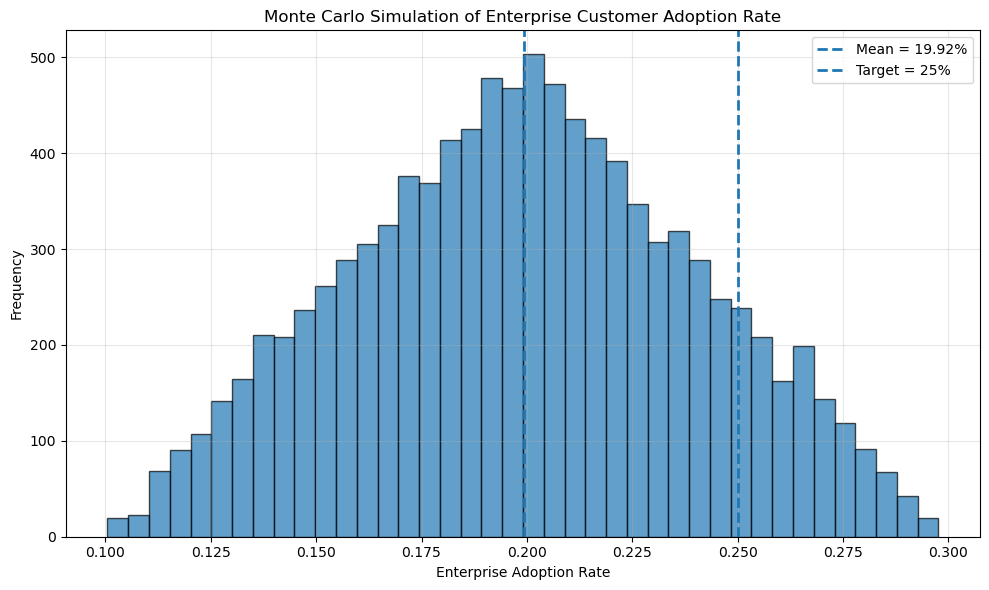

In [6]:
plt.figure(figsize=(10, 6))

plt.hist(
    adoption_rates,
    bins=40,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    mean_adoption,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_adoption:.2%}"
)

plt.axvline(
    target_rate,
    linestyle="--",
    linewidth=2,
    label=f"Target = {target_rate:.0%}"
)

plt.title("Monte Carlo Simulation of Enterprise Customer Adoption Rate")
plt.xlabel("Enterprise Adoption Rate")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("monte_carlo_adoption_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Cumulative Probability Curve

The cumulative probability curve helps identify decision thresholds. For example, the 90th percentile indicates that 90% of simulated adoption outcomes are at or below that adoption rate.

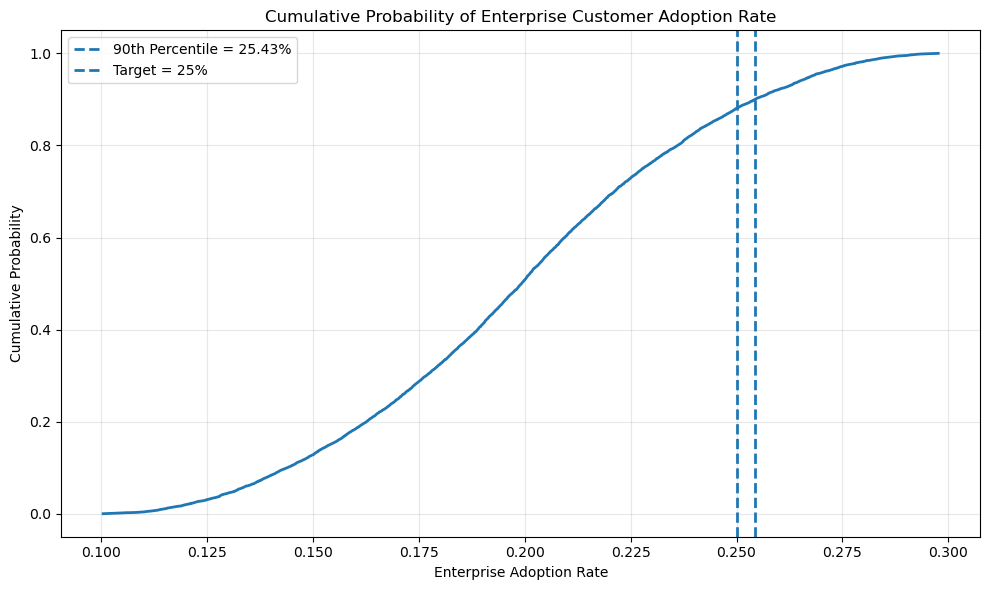

In [7]:
cdf_df = adoption_df.sort_values(by="Enterprise Adoption Rate").reset_index(drop=True)
cdf_df["Cumulative Probability"] = (np.arange(len(cdf_df)) + 1) / len(cdf_df)

plt.figure(figsize=(10, 6))
plt.plot(cdf_df["Enterprise Adoption Rate"], cdf_df["Cumulative Probability"], linewidth=2)
plt.axvline(p90, linestyle="--", linewidth=2, label=f"90th Percentile = {p90:.2%}")
plt.axvline(target_rate, linestyle="--", linewidth=2, label=f"Target = {target_rate:.0%}")
plt.title("Cumulative Probability of Enterprise Customer Adoption Rate")
plt.xlabel("Enterprise Adoption Rate")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("monte_carlo_adoption_cdf.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. I&W Threshold Comparison

The Monte Carlo result can be compared with the Indicators and Warnings framework. Since the simulated mean adoption rate is close to 20%, Amazon is near the boundary between the yellow and green zones.

In [8]:
iw_comparison = pd.DataFrame({
    "Indicator": ["Enterprise Customer Adoption Rate"],
    "Red Threshold": ["< 10%"],
    "Yellow Threshold": ["10% - 20%"],
    "Green Threshold": ["> 20%"],
    "Simulation Result": [f"{mean_adoption:.2%}"],
    "Interpretation": ["Near the yellow/green boundary; monitor closely"]
})

iw_comparison

,Indicator,Red Threshold,Yellow Threshold,Green Threshold,Simulation Result,Interpretation
0,Enterprise Customer Adoption Rate,< 10%,10% - 20%,> 20%,19.92%,Near the yellow/green boundary; monitor closely


## 10. Interpretation

The simulation produced a mean adoption rate of approximately **19.92%**, which is very close to the most likely estimate of **20%**. This suggests that Amazon’s enterprise adoption opportunity is expected to develop at a moderate but meaningful level under the current assumptions.

The target adoption rate was set at **25%** to represent a stronger growth scenario. The simulation shows that the probability of exceeding the 25% target is approximately **12%**, which indicates that reaching stronger adoption levels is possible but not the most likely outcome without additional strategic action.

Most simulated outcomes fall between roughly **15% and 25%**, meaning the opportunity is promising but not guaranteed. Amazon should not assume that rapid enterprise adoption will occur automatically. Instead, it should actively improve adoption conditions through customer onboarding, stronger enterprise support, competitive pricing, and clearer communication of the value of Amazon Connect and AWS Bedrock.

Strategically, the result supports the I&W framework. Enterprise customer adoption should remain a key monitoring indicator. If adoption stays below 20%, Amazon may need to strengthen customer success support, improve product integration, and respond more aggressively to competitors such as Microsoft, Google, Salesforce, and IBM.